# Phase 3 — Exploratory Data Analysis (NASA C-MAPSS FD001)

Goals:
1. See how sensors evolve as a single engine runs to failure.
2. Build a sensor correlation matrix and **drop constant / uninformative sensors**.
3. Show the RUL distribution and the **class imbalance** created by the 125 cap.

All key plots are saved as PNGs into `reports/figures/` for the README.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make src/ importable whether run from repo root or notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data import SENSOR_COLS, SETTING_COLS, download_data, load_train
from targets import RUL_CAP, prepare_train_targets

# Output dir for README figures.
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print("figures ->", FIG_DIR)

Matplotlib is building the font cache; this may take a moment.


figures -> D:\ui ux\predictive-maintenance\reports\figures


In [2]:
# Load train and attach the capped RUL target from Phase 2.
download_data()
train = prepare_train_targets(load_train(), cap=RUL_CAP)
print(train.shape)
train.head()

[data] FD001 files already present in D:\ui ux\predictive-maintenance\data\raw — skipping download.
(20631, 27)


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


## 1. Run-to-failure: one engine, multiple sensors

We plot a few sensors for engine 1 against cycle. Degradation should show up as
a monotone drift in the cycles before failure (right edge).

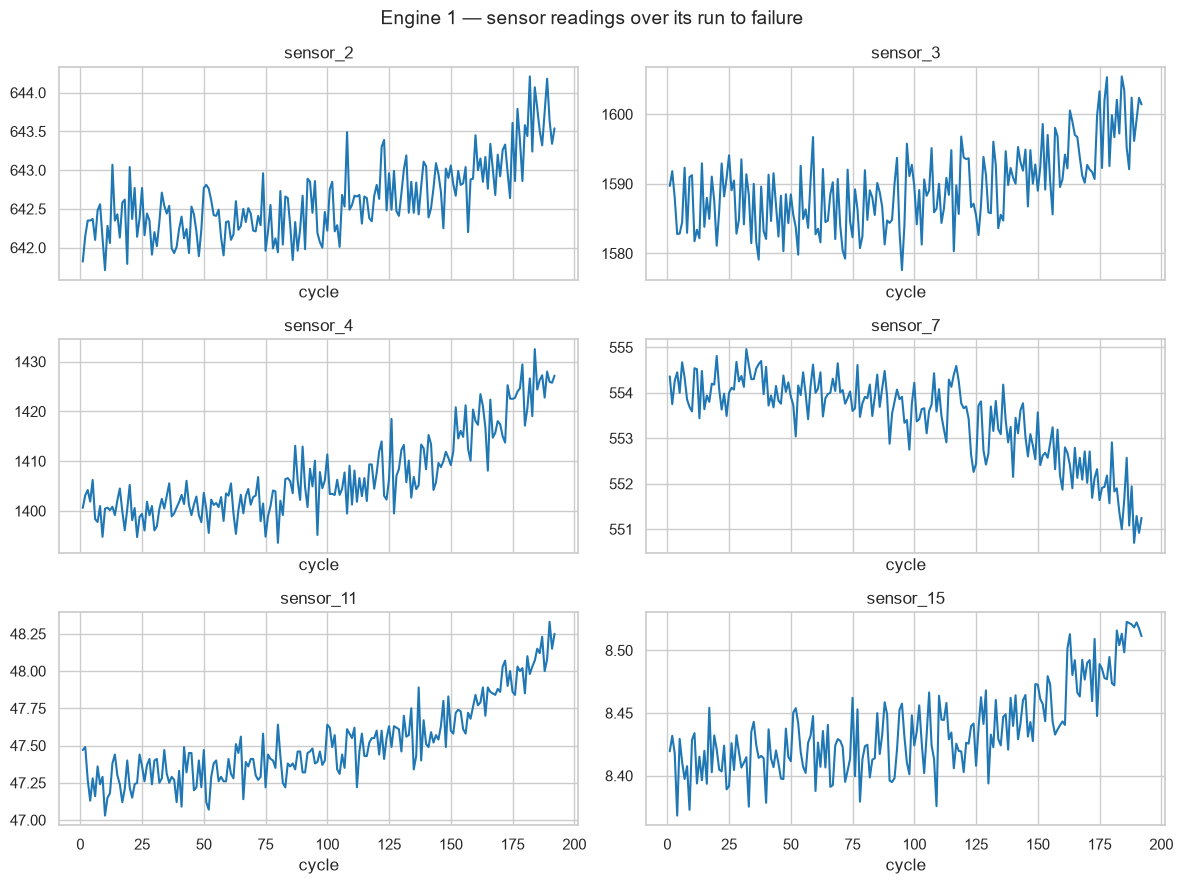

In [3]:
# Six sensors that are known to carry degradation signal in FD001.
signal_sensors = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_11", "sensor_15"]

eng = train[train["unit_number"] == 1]
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for ax, s in zip(axes.ravel(), signal_sensors):
    ax.plot(eng["time_cycles"], eng[s], color="tab:blue")
    ax.set_title(s)
    ax.set_xlabel("cycle")
fig.suptitle("Engine 1 — sensor readings over its run to failure", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "run_to_failure_engine1.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Identify & drop constant / uninformative sensors

In FD001 several sensors (and one operational setting) never change — their
standard deviation is ~0, so they carry **zero predictive information** and only
add noise/compute. We detect them automatically by std, then drop them.

In [4]:
# Standard deviation of every sensor + setting across the whole train set.
candidate_cols = SETTING_COLS + SENSOR_COLS
stds = train[candidate_cols].std().sort_values()

# A column with (near) zero variance is constant -> uninformative.
STD_THRESHOLD = 1e-6
constant_cols = stds[stds <= STD_THRESHOLD].index.tolist()
print("Constant / uninformative columns (std ~ 0):")
print(stds[stds <= STD_THRESHOLD].to_string())
print("\n-> dropping:", constant_cols)

Constant / uninformative columns (std ~ 0):
op_setting_3    0.000000e+00
sensor_1        0.000000e+00
sensor_19       0.000000e+00
sensor_18       0.000000e+00
sensor_10       0.000000e+00
sensor_16       1.387812e-17
sensor_5        1.776400e-15

-> dropping: ['op_setting_3', 'sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5']


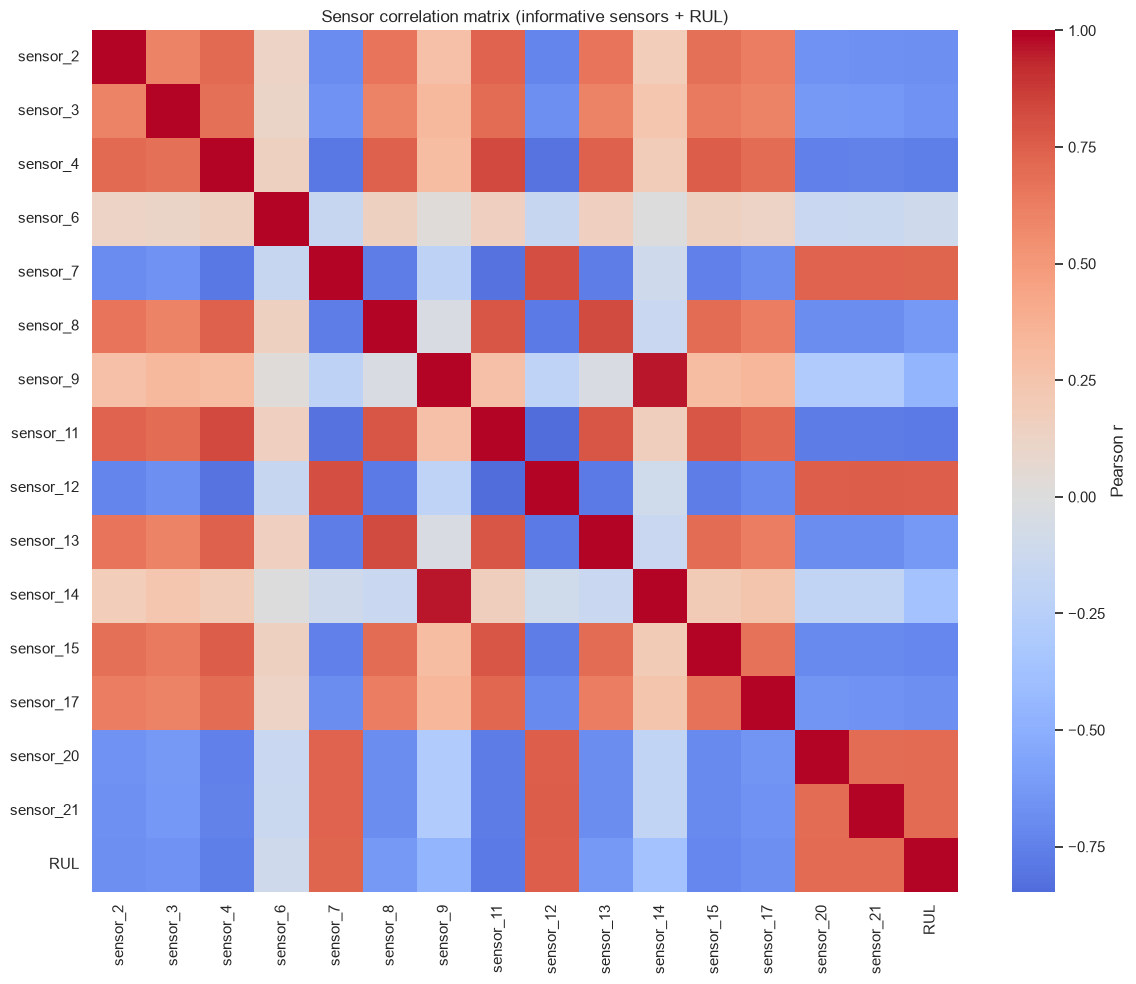

In [5]:
# Keep only informative sensors for the correlation view.
informative_sensors = [c for c in SENSOR_COLS if c not in constant_cols]

corr = train[informative_sensors + ["RUL"]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Sensor correlation matrix (informative sensors + RUL)")
fig.tight_layout()
fig.savefig(FIG_DIR / "sensor_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
# Which sensors correlate most strongly with RUL? (linear signal strength)
rul_corr = corr["RUL"].drop("RUL").sort_values(key=np.abs, ascending=False)
print("Sensors ranked by |correlation with RUL|:")
print(rul_corr.to_string())

Sensors ranked by |correlation with RUL|:
sensor_11   -0.775230
sensor_4    -0.757157
sensor_12    0.748870
sensor_7     0.733021
sensor_15   -0.720858
sensor_21    0.707334
sensor_20    0.704626
sensor_17   -0.680829
sensor_2    -0.678458
sensor_3    -0.655030
sensor_8    -0.624568
sensor_13   -0.624034
sensor_9    -0.462151
sensor_14   -0.369753
sensor_6    -0.108289


## 3. RUL distribution & class imbalance

After the 125 cap, a large share of rows pile up exactly at RUL = 125 (every
early-life cycle of every engine). The model sees the 'healthy' state far more
often than the rare, decision-critical near-failure states.

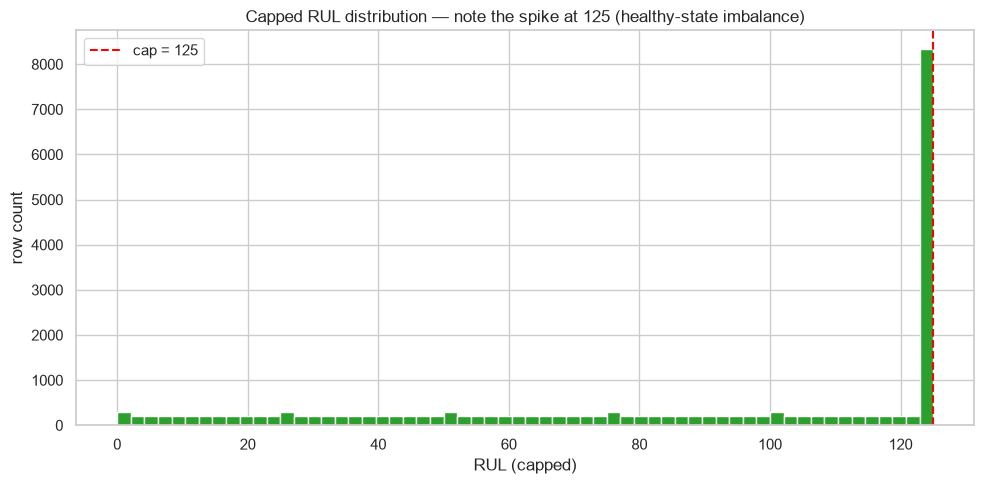

39.4% of all train rows sit exactly at the 125 cap.


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train["RUL"], bins=60, color="tab:green", edgecolor="white")
ax.axvline(RUL_CAP, color="red", linestyle="--", label=f"cap = {RUL_CAP}")
ax.set_xlabel("RUL (capped)")
ax.set_ylabel("row count")
ax.set_title("Capped RUL distribution — note the spike at 125 (healthy-state imbalance)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "rul_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

pct_at_cap = (train["RUL"] == RUL_CAP).mean() * 100
print(f"{pct_at_cap:.1f}% of all train rows sit exactly at the {RUL_CAP} cap.")

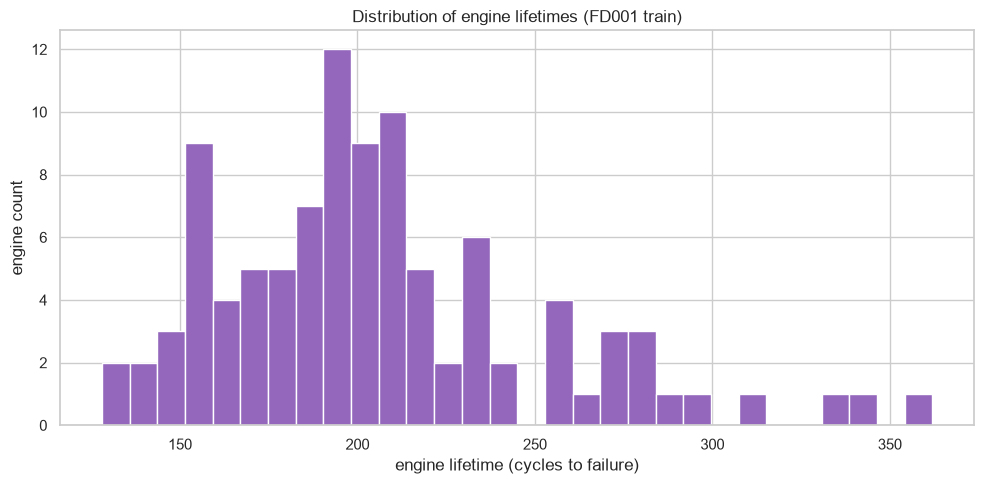

lifetime: min=128, median=199, max=362


In [8]:
# Distribution of engine lifetimes (how long engines survive before failure).
lifetimes = train.groupby("unit_number")["time_cycles"].max()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(lifetimes, bins=30, color="tab:purple", edgecolor="white")
ax.set_xlabel("engine lifetime (cycles to failure)")
ax.set_ylabel("engine count")
ax.set_title("Distribution of engine lifetimes (FD001 train)")
fig.tight_layout()
fig.savefig(FIG_DIR / "engine_lifetimes.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"lifetime: min={lifetimes.min()}, median={int(lifetimes.median())}, max={lifetimes.max()}")

### EDA takeaways
- Constant sensors (std~0) carry no signal and are dropped before modelling.
- A handful of sensors (e.g. 4, 11, 12, 7, 15) drift strongly with RUL — these
  drive the model.
- The capped target is imbalanced toward the healthy state (spike at 125), which
  motivates the cost-sensitive evaluation in Phase 6.